# Prédiction d'acceptation de crédit — Classification binaire


## Objectif

On dispose d'un fichier `Loan_prediction_dataset.csv` contenant des demandes de crédit bancaire. Pour chaque client, on connaît son profil (genre, statut marital, revenus, montant demandé, historique de crédit, etc.) et on sait si sa demande a été **acceptée (`Y`)** ou **refusée (`N`)**.

**Notre objectif :** construire un modèle qui prédit `Loan_Status` (Y/N) à partir du profil du client. C'est une tâche de **classification binaire**.

## Le workflow qu'on va suivre (les 8 étapes du cours)

1. **CHARGER** — `pd.read_csv()`
2. **INSPECTER** — `.head()`, `.info()`, `.isna().sum()`
3. **EXPLORER (EDA)** — histogrammes, boxplots, scatter
4. **SPLIT** — `train_test_split` avec `stratify`
5. **PIPELINE** — `ColumnTransformer` + imputer + scaler + encoder
6. **BASELINE** — `DummyClassifier`
7. **MODÈLE** — `LogisticRegression`
8. **ÉVALUATION** — métriques + matrice de confusion + courbes + validation croisée

Chaque section ci-dessous explique **pourquoi** on fait chaque chose, pas seulement **comment**.

##  Dictionnaire des variables

Avant de toucher au code, voici à quoi correspond chaque colonne du dataset (comme dans le cours §3.1 pour les manchots) :

| Colonne | Description | Type | Rôle |
|---|---|---|---|
| `Loan_ID` | Identifiant unique de la demande (ex : `LP001002`) | Texte | Inutile pour prédire — sera retiré |
| `Gender` | Genre du demandeur (`Male`/`Female`) | Catégoriel | Feature |
| `Married` | Statut marital (`Yes`/`No`) | Catégoriel | Feature |
| `Dependents` | Nombre de personnes à charge (`0`, `1`, `2`, `3+`) | Catégoriel (texte, car `"3+"` n'est pas un nombre) | Feature |
| `Education` | Niveau d'études (`Graduate`/`Not Graduate`) | Catégoriel | Feature |
| `Self_Employed` | Travailleur indépendant ? (`Yes`/`No`) | Catégoriel | Feature |
| `ApplicantIncome` | Revenu mensuel du demandeur | Numérique | Feature |
| `CoapplicantIncome` | Revenu mensuel du co-demandeur (conjoint, etc.) | Numérique | Feature |
| `LoanAmount` | Montant du prêt demandé (en milliers) | Numérique | Feature |
| `Loan_Amount_Term` | Durée du prêt (en mois) | Numérique | Feature |
| `Credit_History` | Le client a-t-il déjà remboursé un crédit correctement ? (`1` = oui, `0` = non) | Catégoriel (c'est un indicateur, pas une quantité) | Feature |
| `Property_Area` | Zone géographique du bien (`Urban`/`Semiurban`/`Rural`) | Catégoriel | Feature |
| `Loan_Status` | Le prêt a-t-il été accordé ? (`Y`/`N`) | Catégoriel (2 classes) | **Cible à prédire** |

**À retenir :** `Loan_ID` n'est qu'un numéro de dossier, il sera exclu des features. Toutes les autres colonnes (sauf `Loan_Status`) décrivent le profil du client et serviront à prédire l'acceptation du prêt.

##  Setup — Importer les bibliothèques

Comme vu dans le cours, on utilise toujours la même équipe d'outils :
- **NumPy** : calcul numérique
- **Pandas** : manipulation de tableaux (notre "Excel en Python")
- **Matplotlib / Seaborn** : visualisation
- **Scikit-learn** : les algorithmes de Machine Learning

In [59]:
pip install numpy pandas matplotlib seaborn scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [60]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, learning_curve
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              roc_auc_score, classification_report, confusion_matrix)

sns.set_theme(style='whitegrid')
RANDOM_STATE = 42  # pour la reproductibilité 

print('Bibliothèques chargées avec succès.')

Bibliothèques chargées avec succès.


---
## Étape 1 — CHARGER

On charge le CSV avec `pd.read_csv()`, comme pour n'importe quel fichier Excel.

In [61]:
df = pd.read_csv('Loan_prediction_dataset.csv')
print('Dataset chargé :', df.shape)
df.head()

Dataset chargé : (614, 13)


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


---
## Étape 2 — INSPECTER

**Astuce du cours :** dès qu'on charge un dataset, les 3 premières choses à faire sont toujours `df.head()`, `df.info()` et `df.isna().sum()`. Ça évite 80 % des bugs.

In [62]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    str    
 1   Gender             601 non-null    str    
 2   Married            611 non-null    str    
 3   Dependents         599 non-null    str    
 4   Education          614 non-null    str    
 5   Self_Employed      582 non-null    str    
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    str    
 12  Loan_Status        614 non-null    str    
dtypes: float64(4), int64(1), str(8)
memory usage: 62.5 KB


In [63]:
# Statistiques rapides sur les colonnes numériques
df.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


In [64]:
# Valeurs manquantes par colonne
print(df.isna().sum())
print()
print('Total de valeurs manquantes :', df.isna().sum().sum())

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

Total de valeurs manquantes : 149


**Ce qu'on observe :**
- Plusieurs colonnes ont des valeurs manquantes (`Gender`, `Married`, `Dependents`, `Self_Employed`, `LoanAmount`, `Loan_Amount_Term`, `Credit_History`).
- `Loan_ID` est juste un identifiant unique (ex : `LP001002`) — il n'apporte **aucune information prédictive**, on le retirera des features.
- `Dependents` contient la valeur texte `"3+"` : ce n'est donc pas une vraie colonne numérique, on la traitera comme catégorielle.
- `Credit_History` est codée en 0/1 mais représente une catégorie (le client a-t-il déjà eu un crédit remboursé correctement ?), pas une quantité qu'on additionne — on la traitera aussi comme catégorielle.

On gérera toutes ces valeurs manquantes **dans le pipeline** (étape 5), jamais en les remplaçant "à la main" avant le split (sinon risque de fuite de données, cf. cours §2.3).

In [65]:
# Distribution de la cible : est-ce équilibré ?
print(df['Loan_Status'].value_counts())
print()
print(df['Loan_Status'].value_counts(normalize=True).round(3))

Loan_Status
Y    422
N    192
Name: count, dtype: int64

Loan_Status
Y    0.687
N    0.313
Name: proportion, dtype: float64


**Important :** la cible est **déséquilibrée** (environ 69 % de `Y` contre 31 % de `N`). On en tiendra compte de deux façons :
- on utilisera `stratify=y` lors du split (étape 4) pour garder cette proportion dans train et test ;
- on ne se fiera pas uniquement à l'**accuracy** pour juger le modèle (cf. cours §2.5 : l'accuracy seule est trompeuse en cas de déséquilibre), on regardera aussi precision, recall, F1 et ROC-AUC.

---
## Étape 3 — EXPLORER (EDA)

 Toujours visualiser ses données AVANT d'entraîner un modèle. On découvre des choses étonnantes : outliers, classes mal équilibrées, corrélations cachées.

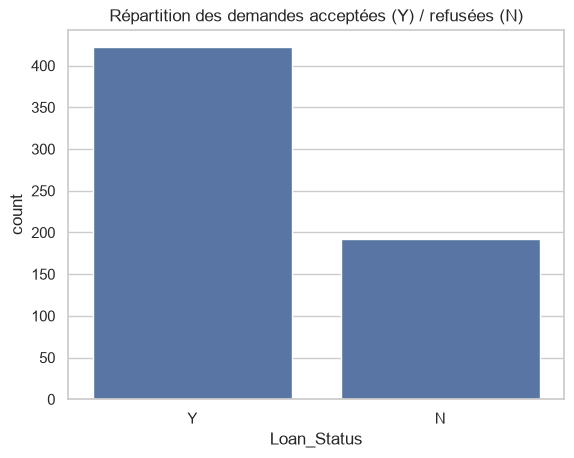

In [66]:
# 1. Répartition de la cible
sns.countplot(data=df, x='Loan_Status')
plt.title("Répartition des demandes acceptées (Y) / refusées (N)")
plt.show()

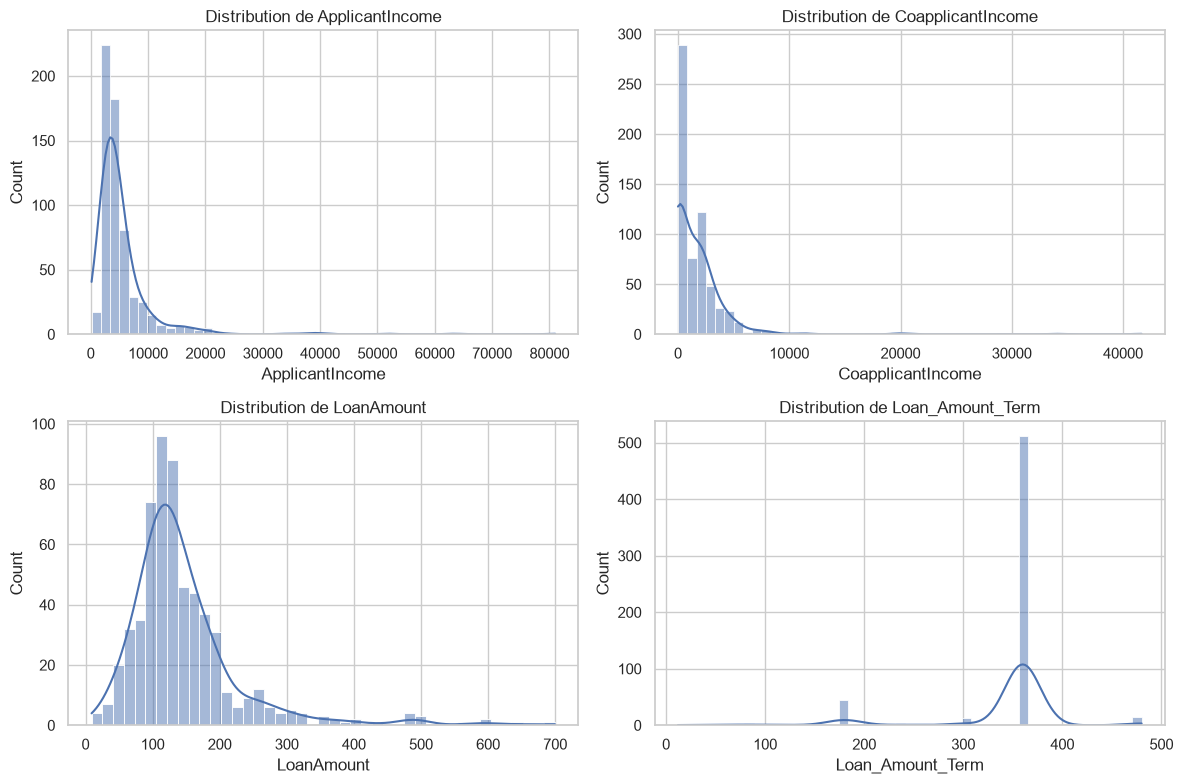

In [67]:
# 2. Histogrammes des variables numériques
num_features = ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term']

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col in zip(axes.flat, num_features):
    sns.histplot(data=df, x=col, kde=True, ax=ax)
    ax.set_title(f'Distribution de {col}')
plt.tight_layout()
plt.show()

**Ce qu'on observe :** `ApplicantIncome`, `CoapplicantIncome` et `LoanAmount` sont très **asymétriques** (quelques clients ont des revenus ou montants très élevés, ce qui étire la distribution vers la droite). C'est normal pour des données financières — on en tiendra compte en standardisant ces colonnes dans le pipeline (la standardisation ne corrige pas l'asymétrie mais met toutes les échelles au même niveau).

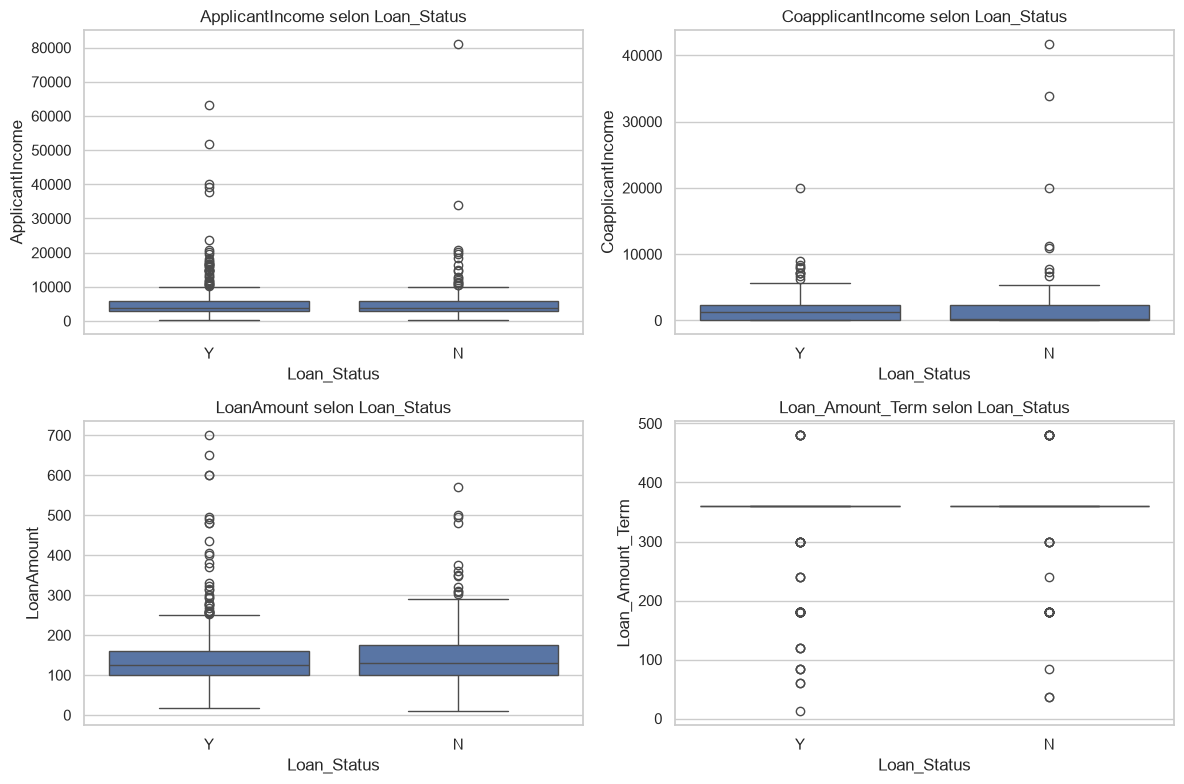

In [68]:
# 3. Boxplots : les variables numériques selon le statut du prêt
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col in zip(axes.flat, num_features):
    sns.boxplot(data=df, x='Loan_Status', y=col, ax=ax)
    ax.set_title(f'{col} selon Loan_Status')
plt.tight_layout()
plt.show()

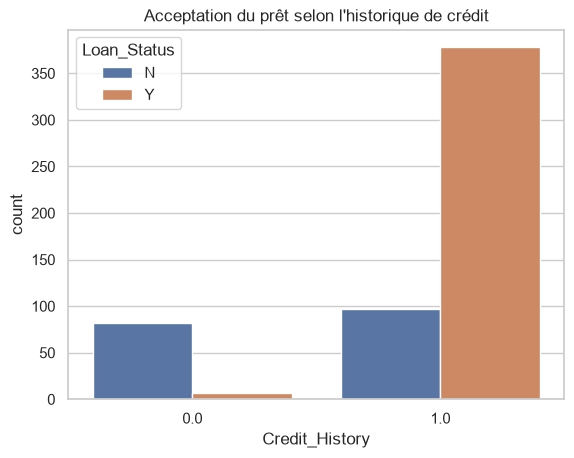

In [69]:
# 4. Crédit accepté selon l'historique de crédit (Credit_History)
sns.countplot(data=df, x='Credit_History', hue='Loan_Status')
plt.title("Acceptation du prêt selon l'historique de crédit")
plt.show()

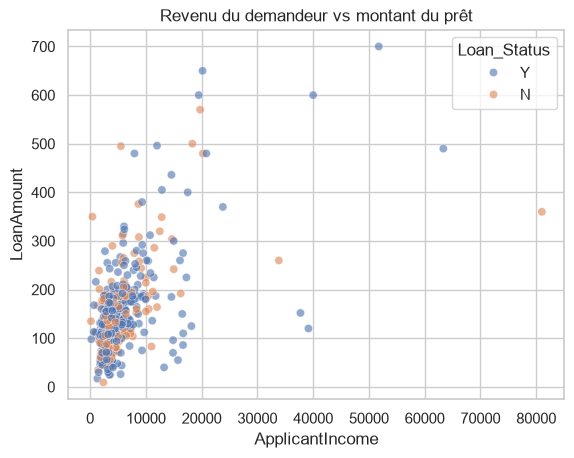

In [70]:
# 5. Relation entre revenu du demandeur et montant du prêt, coloré par le statut
sns.scatterplot(data=df, x='ApplicantIncome', y='LoanAmount', hue='Loan_Status', alpha=0.6)
plt.title("Revenu du demandeur vs montant du prêt")
plt.show()

**Ce qu'on apprend de l'EDA :**
- `Credit_History` semble **fortement liée** à l'acceptation : très peu de clients avec `Credit_History = 0` obtiennent leur prêt. C'est probablement notre feature la plus discriminante.
- Le revenu et le montant du prêt seuls ne séparent pas clairement les deux classes — il faudra combiner plusieurs variables.
- Quelques valeurs extrêmes (outliers) sur les revenus, mais rien d'aberrant au point de devoir les supprimer.

---
## Étape 4 — SPLIT

On sépare **features (X)** et **cible (y)**, puis on découpe en train/test.

**Règle sacrée du cours :** l'ensemble de test ne doit jamais influencer une décision avant la toute fin. On le met de côté maintenant et on n'y touche plus jusqu'à l'évaluation finale.

On retire `Loan_ID` (identifiant, aucune valeur prédictive) et on utilise `stratify=y` pour préserver la proportion Y/N dans train et test .

In [71]:
# Features et cible
X = df.drop(columns=['Loan_ID', 'Loan_Status'])
y = df['Loan_Status']

print('X shape :', X.shape)
print('Colonnes de X :', list(X.columns))

# Split 80% train / 20% test, en conservant les proportions de classes
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)

print(f'\nTrain : {X_train.shape}, Test : {X_test.shape}')
print('\nProportion Y/N dans le train :')
print(y_train.value_counts(normalize=True).round(3))
print('\nProportion Y/N dans le test :')
print(y_test.value_counts(normalize=True).round(3))

X shape : (614, 11)
Colonnes de X : ['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History', 'Property_Area']

Train : (491, 11), Test : (123, 11)

Proportion Y/N dans le train :
Loan_Status
Y    0.686
N    0.314
Name: proportion, dtype: float64

Proportion Y/N dans le test :
Loan_Status
Y    0.691
N    0.309
Name: proportion, dtype: float64


---
## Étape 5 — PIPELINE

On a deux types de colonnes, chacune avec un traitement différent (cf. cours §3.5) :

- **Colonnes numériques** (`ApplicantIncome`, `CoapplicantIncome`, `LoanAmount`, `Loan_Amount_Term`) : on impute la **médiane** (robuste aux valeurs extrêmes vues dans l'EDA), puis on **standardise** avec `StandardScaler`.
- **Colonnes catégorielles** (`Gender`, `Married`, `Dependents`, `Education`, `Self_Employed`, `Credit_History`, `Property_Area`) : on impute la valeur la **plus fréquente**, puis on encode en 0/1 avec `OneHotEncoder`.

**Pourquoi un `Pipeline` ?** Pour éviter systématiquement la fuite de données : le `fit` (apprentissage des statistiques d'imputation/standardisation) ne se fera que sur le train, jamais sur le test (cf. cours §2.3 — le piège silencieux).

In [72]:
num_cols = ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term']
cat_cols = ['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed',
            'Credit_History', 'Property_Area']

# Pipeline pour les colonnes numériques : imputer la médiane, puis standardiser
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Pipeline pour les colonnes catégorielles : imputer le mode, puis one-hot encoder
cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# On combine les deux avec un ColumnTransformer
preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_cols),
    ('cat', cat_pipeline, cat_cols)
])

print('Préprocesseur construit.')
print(f'  {len(num_cols)} colonnes numériques : {num_cols}')
print(f'  {len(cat_cols)} colonnes catégorielles : {cat_cols}')

Préprocesseur construit.
  4 colonnes numériques : ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term']
  7 colonnes catégorielles : ['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'Credit_History', 'Property_Area']


---
## Étape 6 — BASELINE

**Pourquoi une baseline ?** Pour avoir un point de comparaison. Si notre vrai modèle ne fait pas mieux qu'un modèle stupide, on n'a rien gagné.

`DummyClassifier(strategy='most_frequent')` prédit **toujours** la classe majoritaire (`Y` dans notre cas, car ~69 % des prêts sont acceptés).

In [73]:
dummy = Pipeline([
    ('prep', preprocessor),
    ('clf', DummyClassifier(strategy='most_frequent', random_state=RANDOM_STATE))
])

dummy.fit(X_train, y_train)
y_pred_dummy = dummy.predict(X_test)

print(f"Baseline accuracy : {accuracy_score(y_test, y_pred_dummy):.3f}")
print(f"Baseline F1 (classe 'Y') : {f1_score(y_test, y_pred_dummy, pos_label='Y'):.3f}")

Baseline accuracy : 0.691
Baseline F1 (classe 'Y') : 0.817


Cette baseline obtient une accuracy élevée **uniquement parce que la classe `Y` est majoritaire** — elle ne « comprend » rien du profil des clients. Toute amélioration future devra **dépasser ce score**, et surtout faire mieux que F1, car un modèle qui prédit toujours `Y` aura un mauvais rappel sur la classe `N`.

---
## Étape 7 — MODÈLE

On entraîne maintenant un vrai modèle : la **régression logistique**, simple et interprétable — toujours un bon point de départ avant d'essayer des modèles plus complexes (cf. cours §3.7).

In [74]:
model = Pipeline([
    ('prep', preprocessor),
    ('clf', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
])

model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, list(model.classes_).index('Y')]  # probabilité de la classe 'Y'

print('Modèle entraîné.')

Modèle entraîné.


---
## Étape 8 — ÉVALUATION

### 8.1 Métriques globales et rapport détaillé

On ne se contente pas de l'accuracy (trompeuse en cas de déséquilibre) : on regarde aussi precision, recall, F1 et ROC-AUC.

In [75]:
y_test_bin = (y_test == 'Y').astype(int)

print(f"Accuracy : {accuracy_score(y_test, y_pred):.3f}")
print(f"Precision (classe 'Y') : {precision_score(y_test, y_pred, pos_label='Y'):.3f}")
print(f"Recall    (classe 'Y') : {recall_score(y_test, y_pred, pos_label='Y'):.3f}")
print(f"F1        (classe 'Y') : {f1_score(y_test, y_pred, pos_label='Y'):.3f}")
print(f"ROC-AUC                : {roc_auc_score(y_test_bin, y_proba):.3f}")
print()
print('Rapport détaillé par classe :')
print(classification_report(y_test, y_pred))

Accuracy : 0.862
Precision (classe 'Y') : 0.840
Recall    (classe 'Y') : 0.988
F1        (classe 'Y') : 0.908
ROC-AUC                : 0.853

Rapport détaillé par classe :
              precision    recall  f1-score   support

           N       0.96      0.58      0.72        38
           Y       0.84      0.99      0.91        85

    accuracy                           0.86       123
   macro avg       0.90      0.78      0.81       123
weighted avg       0.88      0.86      0.85       123



### 8.2 Matrice de confusion

La matrice de confusion permet de voir précisément quel **type d'erreur** le modèle commet : refuse-t-il des clients qui auraient dû être acceptés (faux négatifs), ou accepte-t-il des clients qui auraient dû être refusés (faux positifs) ? Dans un contexte bancaire, ces deux erreurs n'ont pas le même coût.

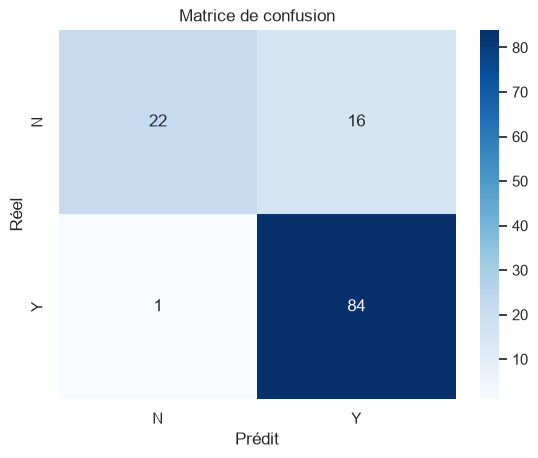

In [76]:
cm = confusion_matrix(y_test, y_pred, labels=['N', 'Y'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['N', 'Y'], yticklabels=['N', 'Y'])
plt.xlabel('Prédit')
plt.ylabel('Réel')
plt.title('Matrice de confusion')
plt.show()

**Lecture de la matrice (résultats obtenus sur les 123 clients du test) :**

|  | Prédit N | Prédit Y |
|---|---|---|
| **Réel N** (38 clients) | 22 (vrais négatifs) | 16 (faux positifs) |
| **Réel Y** (85 clients) | 1 (faux négatif) | 84 (vrais positifs) |

- **22 vrais négatifs** : clients refusés à juste titre.
- **84 vrais positifs** : clients acceptés à juste titre — la grande majorité des cas, car la classe `Y` est majoritaire dans le dataset.
- **1 seul faux négatif** : un client qui aurait dû être accepté a été refusé. Le modèle est donc très prudent à ne presque jamais rater un bon client (recall de 0.99 sur `Y`, cf. §8.1).
- **16 faux positifs** : c'est l'erreur dominante du modèle — 16 clients sur 38 qui auraient dû être refusés (42 % des `N`) ont été prédits `Y` par erreur. C'est cohérent avec le recall de seulement 0.58 sur la classe `N` vu dans le rapport détaillé.

**Pourquoi ce déséquilibre d'erreurs ?** Le modèle a beaucoup plus d'exemples de `Y` (422) que de `N` (192) pour apprendre — il a donc plus de mal à reconnaître un profil "à risque" qu'un profil "sûr". C'est un effet classique du déséquilibre de classes (cf. cours §2.5), et c'est précisément ce type d'erreur (faux positifs sur `Y` = prêts accordés à des clients qui auraient dû être refusés) qu'on cherche à réduire à l'étape 9.3 en relevant le seuil de décision.

### 8.3 Validation croisée pour confirmer

Un seul split train/test dépend du hasard de la découpe . On confirme nos résultats avec une validation croisée à 5 folds, en utilisant `StratifiedKFold` pour respecter les proportions de classes dans chaque fold.

In [77]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='accuracy')

print(f"Accuracy CV : {scores.mean():.3f} +/- {scores.std():.3f}")
print(f"Scores par fold : {scores.round(3)}")

Accuracy CV : 0.798 +/- 0.044
Scores par fold : [0.838 0.806 0.827 0.714 0.806]


Si l'écart-type est petit, on peut faire confiance à notre estimation : le modèle se comporte de façon stable, quelle que soit la portion du train utilisée pour valider.

### 8.4 Courbe d'apprentissage

La courbe d'apprentissage trace l'erreur en fonction de la taille du train. Elle répond à la question : « mon modèle a-t-il besoin de plus de données, ou souffre-t-il de sous-/sur-apprentissage ? » .

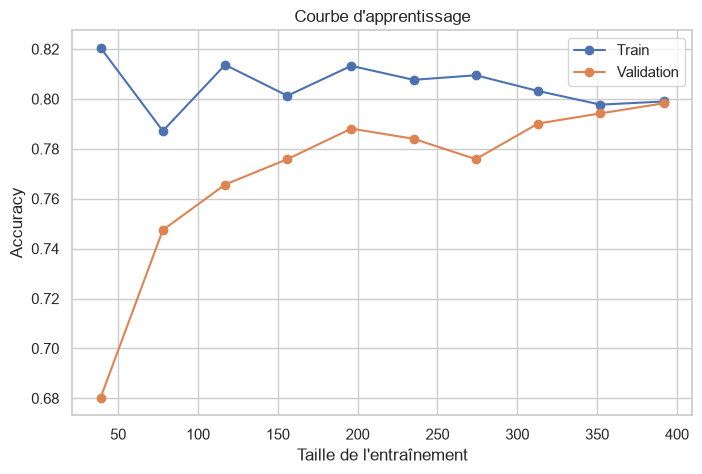

In [78]:
train_sizes, train_scores, val_scores = learning_curve(
    model, X_train, y_train,
    train_sizes=np.linspace(0.1, 1.0, 10),
    cv=cv, scoring='accuracy', random_state=RANDOM_STATE
)

plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_scores.mean(axis=1), 'o-', label='Train')
plt.plot(train_sizes, val_scores.mean(axis=1), 'o-', label='Validation')
plt.xlabel("Taille de l'entraînement")
plt.ylabel('Accuracy')
plt.title("Courbe d'apprentissage")
plt.legend()
plt.grid(True)
plt.show()

**Lecture :** si les courbes train et validation convergent vers une valeur proche, le modèle a un bon équilibre. Si la courbe de validation continue de monter franchement, on bénéficierait de plus de données. Si l'écart train/validation reste très grand, c'est un signal de sur-apprentissage.

---
##  Bilan

On a suivi le workflow complet , appliqué à un vrai problème métier (acceptation de crédit) :

1. **Chargé** le dataset avec `pd.read_csv()`.
2. **Inspecté** : valeurs manquantes, types, déséquilibre de la cible (~69 % Y / 31 % N).
3. **Exploré** visuellement : `Credit_History` ressort comme la variable la plus discriminante.
4. **Splitté** en train/test avec `stratify=y` pour préserver le déséquilibre.
5. **Construit un pipeline** : imputer + scaler pour le numérique, imputer + one-hot pour le catégoriel — zéro fuite de données.
6. **Établi une baseline** avec `DummyClassifier` pour avoir un point de comparaison.
7. **Entraîné un modèle** de régression logistique.
8. **Évalué** avec accuracy/precision/recall/F1/ROC-AUC, matrice de confusion, validation croisée et courbe d'apprentissage.



**Limite** Jusqu'ici, `model.predict()` utilise un **seuil implicite de 0.5** : si la probabilité prédite de `Y` dépasse 50 %, on prédit `Y`. Mais ce seuil n'a rien de spécial — c'est juste la valeur par défaut.

Dans un contexte bancaire, les deux types d'erreurs n'ont **pas le même coût** :
- **Faux positif** (le modèle prédit `Y`, mais le client ne remboursera pas) : la banque perd l'argent prêté — coût potentiellement élevé.
- **Faux négatif** (le modèle prédit `N`, mais le client aurait remboursé) : la banque perd un client et des intérêts — coût réel, mais en général plus faible qu'un défaut de paiement.

Si l'on juge qu'un faux positif coûte plus cher qu'un faux négatif, on doit être **plus exigeant** pour accorder un prêt : augmenter le seuil de décision au-delà de 0.5 (n'accorder le prêt que si la probabilité de remboursement est très élevée). On regarde comment precision et recall évoluent selon le seuil choisi.